# HFENN Regression - 单受试者Sigmoid标签测试

## 目的
对比线性插值标签和Sigmoid标签在单个受试者上的训练效果，观察：
1. Loss下降速度是否更快
2. 最终R²是否更高
3. 预测曲线是否更符合真实疲劳演变

## 测试受试者
使用 **gs1** 作为测试对象

In [1]:
# === Cell 1: 环境设置 ===
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime
import random

from scipy.signal import find_peaks, hilbert, welch
from scipy.stats import skew, kurtosis
import pywt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

try:
    from keras import layers, models, Input, regularizers
    from keras.optimizers import Adam
    from keras.callbacks import ReduceLROnPlateau, EarlyStopping
    import keras.backend as K
    print("使用独立的 keras")
except ImportError:
    from tensorflow.keras import layers, models, Input, regularizers
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
    import tensorflow.keras.backend as K
    print("使用 tensorflow.keras")

np.random.seed(42)
random.seed(42)

TEST_PARTICIPANT = 'gs1'
print(f"单受试者测试: {TEST_PARTICIPANT}")
print(f"开始时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

使用独立的 keras
单受试者测试: gs1
开始时间: 2026-01-05 10:57:41


In [2]:
# === Cell 2: 加载两种标签的数据 ===
print("加载数据...")

# 线性标签数据
df_linear = pd.read_csv(f'data/processed/{TEST_PARTICIPANT}_continuous.csv')
print(f"线性标签数据: {len(df_linear)} 行")

# Sigmoid标签数据
df_sigmoid = pd.read_csv(f'data/processed_sigmoid/{TEST_PARTICIPANT}_continuous.csv')
print(f"Sigmoid标签数据: {len(df_sigmoid)} 行")

# 数据清理
df_linear.dropna(inplace=True)
df_sigmoid.dropna(inplace=True)

# 按参与者Z-Score标准化
def per_participant_standardization(df, columns):
    df_std = df.copy()
    for col in columns:
        mean_val = df[col].mean()
        std_val = df[col].std()
        if std_val > 0:
            df_std[col] = (df[col] - mean_val) / std_val
        else:
            df_std[col] = 0
    return df_std

df_linear = per_participant_standardization(df_linear, ['Pulse', 'Fatigue'])
df_sigmoid = per_participant_standardization(df_sigmoid, ['Pulse', 'Fatigue'])

# 添加差分信号
def add_diff_signals(df):
    df_with_diff = df.copy()
    df_with_diff['Pulse_Diff'] = df['Pulse'].diff().fillna(0)
    df_with_diff['Fatigue_Diff'] = df['Fatigue'].diff().fillna(0)
    return df_with_diff

df_linear = add_diff_signals(df_linear)
df_sigmoid = add_diff_signals(df_sigmoid)

print(f"\n标签对比:")
print(f"  线性标签范围: [{df_linear['Fatigue_Score_Smoothed'].min():.4f}, {df_linear['Fatigue_Score_Smoothed'].max():.4f}]")
print(f"  Sigmoid标签范围: [{df_sigmoid['Fatigue_Score_Smoothed'].min():.4f}, {df_sigmoid['Fatigue_Score_Smoothed'].max():.4f}]")

加载数据...
线性标签数据: 294177 行
Sigmoid标签数据: 294177 行

标签对比:
  线性标签范围: [0.0000, 1.0000]
  Sigmoid标签范围: [0.0012, 1.0000]


In [3]:
# === Cell 3: 特征提取器 ===
class QuadChannelFeatureExtractor:
    def __init__(self, sampling_rate=87):
        self.sampling_rate = sampling_rate
        
    def extract_time_domain_features(self, signal):
        features = []
        features.extend([
            np.mean(signal), np.std(signal), np.max(signal), np.min(signal),
            np.median(signal), skew(signal), kurtosis(signal), np.var(signal),
            np.ptp(signal), np.percentile(signal, 25), np.percentile(signal, 75),
            len(find_peaks(signal)[0]), len(find_peaks(-signal)[0]),
            np.sum(signal**2), np.mean(signal**2), np.sqrt(np.mean(signal**2)),
        ])
        return features
    
    def extract_frequency_domain_features(self, signal):
        features = []
        freqs, psd = welch(signal, fs=self.sampling_rate, nperseg=min(256, len(signal)//4))
        features.extend([np.mean(psd), np.std(psd), np.max(psd),
                        freqs[np.argmax(psd)] if len(psd) > 0 else 0, np.sum(psd)])
        freq_bands = [(0, 1), (1, 5), (5, 15), (15, 25)]
        total_power = np.sum(psd)
        for low, high in freq_bands:
            band_mask = (freqs >= low) & (freqs <= high)
            band_power = np.sum(psd[band_mask])
            features.append(band_power / total_power if total_power > 0 else 0)
        return features
    
    def extract_wavelet_features(self, signal):
        features = []
        coeffs = pywt.wavedec(signal, 'db4', level=4)
        for coeff in coeffs:
            if len(coeff) > 0:
                features.extend([np.mean(coeff), np.std(coeff), np.sum(coeff**2), np.max(np.abs(coeff))])
        return features
    
    def extract_nonlinear_features(self, signal):
        features = []
        analytic_signal = hilbert(signal)
        amplitude_envelope = np.abs(analytic_signal)
        instantaneous_phase = np.angle(analytic_signal)
        features.extend([np.mean(amplitude_envelope), np.std(amplitude_envelope),
                        np.mean(np.diff(instantaneous_phase))])
        zero_crossings = np.sum(np.diff(np.sign(signal - np.mean(signal))) != 0) / len(signal)
        features.append(zero_crossings)
        return features
    
    def extract_diff_features(self, diff_signal):
        features = []
        features.extend([
            np.mean(diff_signal), np.std(diff_signal), np.max(diff_signal), np.min(diff_signal),
            np.sum(diff_signal > 0) / len(diff_signal), np.sum(diff_signal < 0) / len(diff_signal),
            np.sum(np.abs(diff_signal)), np.mean(np.abs(diff_signal)),
            skew(diff_signal), kurtosis(diff_signal),
        ])
        return features
    
    def extract_single_channel_features(self, signal):
        all_features = []
        all_features.extend(self.extract_time_domain_features(signal))
        all_features.extend(self.extract_frequency_domain_features(signal))
        all_features.extend(self.extract_wavelet_features(signal))
        all_features.extend(self.extract_nonlinear_features(signal))
        return np.array(all_features)
    
    def extract_quad_channel_features(self, pulse, fatigue, pulse_diff, fatigue_diff):
        pulse_features = self.extract_single_channel_features(pulse)
        fatigue_features = self.extract_single_channel_features(fatigue)
        pulse_diff_features = self.extract_diff_features(pulse_diff)
        fatigue_diff_features = self.extract_diff_features(fatigue_diff)
        return np.concatenate([pulse_features, fatigue_features, pulse_diff_features, fatigue_diff_features])

feature_extractor = QuadChannelFeatureExtractor()
print("特征提取器构建完成")

特征提取器构建完成


In [4]:
# === Cell 4: 数据分段函数 ===
def extract_segments(df, window_size=2610, overlap_ratio=0.5):
    step = int(window_size * (1 - overlap_ratio))
    pulse_segments, fatigue_segments, enhanced_features = [], [], []
    target_values = []
    
    pulse_data = df['Pulse'].values
    fatigue_data = df['Fatigue'].values
    pulse_diff_data = df['Pulse_Diff'].values
    fatigue_diff_data = df['Fatigue_Diff'].values
    target_data = df['Fatigue_Score_Smoothed'].values
    
    for start in range(0, len(pulse_data) - window_size + 1, step):
        end = start + window_size
        pulse_seg = pulse_data[start:end]
        fatigue_seg = fatigue_data[start:end]
        pulse_diff_seg = pulse_diff_data[start:end]
        fatigue_diff_seg = fatigue_diff_data[start:end]
        target_seg = target_data[start:end]
        
        pulse_segments.append(pulse_seg)
        fatigue_segments.append(fatigue_seg)
        features = feature_extractor.extract_quad_channel_features(
            pulse_seg, fatigue_seg, pulse_diff_seg, fatigue_diff_seg)
        enhanced_features.append(features)
        target_values.append(target_seg[-1])
    
    return (np.array(pulse_segments), np.array(fatigue_segments), 
            np.array(enhanced_features), np.array(target_values))

print("数据分段函数定义完成")

数据分段函数定义完成


In [5]:
# === Cell 5: 提取两种标签的数据 ===
print("提取线性标签数据...")
pulse_linear, fatigue_linear, features_linear, targets_linear = extract_segments(df_linear)
features_linear = np.nan_to_num(features_linear, nan=0.0, posinf=0.0, neginf=0.0)
print(f"  样本数: {len(targets_linear)}, 特征数: {features_linear.shape[1]}")

print("提取Sigmoid标签数据...")
pulse_sigmoid, fatigue_sigmoid, features_sigmoid, targets_sigmoid = extract_segments(df_sigmoid)
features_sigmoid = np.nan_to_num(features_sigmoid, nan=0.0, posinf=0.0, neginf=0.0)
print(f"  样本数: {len(targets_sigmoid)}, 特征数: {features_sigmoid.shape[1]}")

提取线性标签数据...
  样本数: 224, 特征数: 118
提取Sigmoid标签数据...
  样本数: 224, 特征数: 118


In [6]:
# === Cell 6: 数据准备函数 ===
def prepare_data(pulse_ts, fatigue_ts, features, targets, test_size=0.2):
    # 特征标准化和选择
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    n_features = min(50, features.shape[1])
    selector = SelectKBest(score_func=f_regression, k=n_features)
    features_selected = selector.fit_transform(features_scaled, targets)
    
    # 准备数据
    X_pulse = pulse_ts.reshape(pulse_ts.shape[0], pulse_ts.shape[1], 1)
    X_fatigue = fatigue_ts.reshape(fatigue_ts.shape[0], fatigue_ts.shape[1], 1)
    X_features = features_selected
    y = targets
    
    # 分割数据
    indices = np.arange(len(y))
    train_idx, test_idx = train_test_split(indices, test_size=test_size, random_state=42)
    
    return {
        'X_pulse_train': X_pulse[train_idx], 'X_pulse_test': X_pulse[test_idx],
        'X_fatigue_train': X_fatigue[train_idx], 'X_fatigue_test': X_fatigue[test_idx],
        'X_feat_train': X_features[train_idx], 'X_feat_test': X_features[test_idx],
        'y_train': y[train_idx], 'y_test': y[test_idx]
    }

print("准备线性标签数据...")
data_linear = prepare_data(pulse_linear, fatigue_linear, features_linear, targets_linear)
print(f"  训练集: {len(data_linear['y_train'])}, 测试集: {len(data_linear['y_test'])}")

print("准备Sigmoid标签数据...")
data_sigmoid = prepare_data(pulse_sigmoid, fatigue_sigmoid, features_sigmoid, targets_sigmoid)
print(f"  训练集: {len(data_sigmoid['y_train'])}, 测试集: {len(data_sigmoid['y_test'])}")

准备线性标签数据...
  训练集: 179, 测试集: 45
准备Sigmoid标签数据...
  训练集: 179, 测试集: 45


In [7]:
# === Cell 7: 小波变换 ===
def wavelet_transform_batch(data, wavelet='db4', level=4):
    n_samples = data.shape[0]
    sample_coeffs = pywt.wavedec(data[0, :, 0], wavelet, level=level)
    coeff_lengths = [len(c) for c in sample_coeffs]
    all_coeffs = [np.zeros((n_samples, length, 1)) for length in coeff_lengths]
    for i in range(n_samples):
        signal = data[i, :, 0]
        coeffs = pywt.wavedec(signal, wavelet, level=level)
        for j, coeff in enumerate(coeffs):
            all_coeffs[j][i, :, 0] = coeff
    return all_coeffs

def prepare_wavelet_data(data):
    # Pulse通道
    pulse_train_coeffs = wavelet_transform_batch(data['X_pulse_train'])
    pulse_test_coeffs = wavelet_transform_batch(data['X_pulse_test'])
    # Fatigue通道
    fatigue_train_coeffs = wavelet_transform_batch(data['X_fatigue_train'])
    fatigue_test_coeffs = wavelet_transform_batch(data['X_fatigue_test'])
    
    return {
        'pulse_train': pulse_train_coeffs, 'pulse_test': pulse_test_coeffs,
        'fatigue_train': fatigue_train_coeffs, 'fatigue_test': fatigue_test_coeffs
    }

print("执行小波变换...")
wavelet_linear = prepare_wavelet_data(data_linear)
wavelet_sigmoid = prepare_wavelet_data(data_sigmoid)
print("小波变换完成")

执行小波变换...
小波变换完成


In [8]:
# === Cell 8: 构建模型 ===
def build_model(wavelet_data, feat_shape):
    def attention_block(x, filters):
        attention = layers.Dense(filters, activation='tanh')(x)
        attention = layers.Dense(filters, activation='softmax')(attention)
        attended = layers.Multiply()([x, attention])
        return attended

    def residual_block(x, filters, kernel_size=3, dropout_rate=0.3):
        shortcut = x
        x = layers.Conv1D(filters, kernel_size, padding='same', kernel_regularizer=regularizers.l2(0.01))(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Dropout(dropout_rate)(x)
        x = layers.Conv1D(filters, kernel_size, padding='same', kernel_regularizer=regularizers.l2(0.01))(x)
        x = layers.BatchNormalization()(x)
        x = layers.add([x, shortcut])
        x = layers.ReLU()(x)
        x = attention_block(x, filters)
        return x

    def build_wavelet_branch(coeff_shapes, prefix, filters=32):
        inputs, outputs = [], []
        names = ['cA4', 'cD4', 'cD3', 'cD2', 'cD1']
        for i, shape in enumerate(coeff_shapes):
            inp = Input(shape=shape, name=f'{prefix}_{names[i]}_input')
            inputs.append(inp)
            x = residual_block(inp, filters)
            x = layers.GlobalMaxPooling1D()(x)
            outputs.append(x)
        merged = layers.Concatenate()(outputs)
        return inputs, merged

    # 获取小波系数形状
    pulse_shapes = [c.shape[1:] for c in wavelet_data['pulse_train']]
    fatigue_shapes = [c.shape[1:] for c in wavelet_data['fatigue_train']]
    
    pulse_inputs, pulse_features = build_wavelet_branch(pulse_shapes, 'pulse')
    fatigue_inputs, fatigue_features = build_wavelet_branch(fatigue_shapes, 'fatigue')
    
    dual_wavelet_features = layers.Concatenate()([pulse_features, fatigue_features])
    
    input_enhanced = Input(shape=feat_shape, name='enhanced_features_input')
    enhanced_branch = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(input_enhanced)
    enhanced_branch = layers.BatchNormalization()(enhanced_branch)
    enhanced_branch = layers.Dropout(0.5)(enhanced_branch)
    enhanced_branch = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(enhanced_branch)
    
    fused = layers.Concatenate()([dual_wavelet_features, enhanced_branch])
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(fused)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation='sigmoid', name='regression_output')(x)
    
    all_inputs = pulse_inputs + fatigue_inputs + [input_enhanced]
    model = models.Model(inputs=all_inputs, outputs=output)
    return model

print("构建模型...")
model_linear = build_model(wavelet_linear, data_linear['X_feat_train'].shape[1:])
model_sigmoid = build_model(wavelet_sigmoid, data_sigmoid['X_feat_train'].shape[1:])
print(f"模型参数量: {model_linear.count_params():,}")

构建模型...
模型参数量: 115,873


In [9]:
# === Cell 9: 编译和训练 ===
try:
    from keras import ops
    def rmse(y_true, y_pred):
        return ops.sqrt(ops.mean(ops.square(y_pred - y_true)))
    def r2_metric(y_true, y_pred):
        ss_res = ops.sum(ops.square(y_true - y_pred))
        ss_tot = ops.sum(ops.square(y_true - ops.mean(y_true)))
        return 1 - ss_res / (ss_tot + 1e-7)
except ImportError:
    import tensorflow as tf
    def rmse(y_true, y_pred):
        return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))
    def r2_metric(y_true, y_pred):
        ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
        ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
        return 1 - ss_res / (ss_tot + 1e-7)

model_linear.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae', rmse, r2_metric])
model_sigmoid.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae', rmse, r2_metric])

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=0),
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
]

def get_train_inputs(data, wavelet):
    return wavelet['pulse_train'] + wavelet['fatigue_train'] + [data['X_feat_train']]

def get_test_inputs(data, wavelet):
    return wavelet['pulse_test'] + wavelet['fatigue_test'] + [data['X_feat_test']]

print("="*60)
print("训练线性标签模型...")
print("="*60)
history_linear = model_linear.fit(
    get_train_inputs(data_linear, wavelet_linear), data_linear['y_train'],
    validation_data=(get_test_inputs(data_linear, wavelet_linear), data_linear['y_test']),
    epochs=50, batch_size=32, callbacks=callbacks, verbose=1
)

print("\n" + "="*60)
print("训练Sigmoid标签模型...")
print("="*60)
history_sigmoid = model_sigmoid.fit(
    get_train_inputs(data_sigmoid, wavelet_sigmoid), data_sigmoid['y_train'],
    validation_data=(get_test_inputs(data_sigmoid, wavelet_sigmoid), data_sigmoid['y_test']),
    epochs=50, batch_size=32, callbacks=callbacks, verbose=1
)

训练线性标签模型...
Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - loss: 7.1305 - mae: 0.3335 - r2_metric: -63.4546 - rmse: 0.4102 - val_loss: 6.7319 - val_mae: 0.2336 - val_r2_metric: -37.4915 - val_rmse: 0.3379 - learning_rate: 0.0010
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 6.6299 - mae: 0.2125 - r2_metric: -69.5064 - rmse: 0.4390 - val_loss: 6.3270 - val_mae: 0.2381 - val_r2_metric: -42.3249 - val_rmse: 0.3578 - learning_rate: 0.0010
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 6.2145 - mae: 0.2016 - r2_metric: -76.8419 - rmse: 0.4531 - val_loss: 5.9259 - val_mae: 0.2338 - val_r2_metric: -43.1750 - val_rmse: 0.3605 - learning_rate: 0.0010
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 5.8199 - mae: 0.1968 - r2_metric: -78.7993 - rmse: 0.4680 - val_loss: 5.5362 - val_mae: 0.2195 - val_r2_metric: -41.8693 - val_rmse: 0.3544 - learning_rate: 0.0010
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 5.4416 - mae: 0.1978 - r2_metric: -77.6452 - r

In [10]:
# === Cell 10: 评估和对比 ===
print("="*60)
print("模型评估对比")
print("="*60)

# 预测
y_pred_linear = model_linear.predict(get_test_inputs(data_linear, wavelet_linear)).flatten()
y_pred_sigmoid = model_sigmoid.predict(get_test_inputs(data_sigmoid, wavelet_sigmoid)).flatten()

# 计算指标
def calc_metrics(y_true, y_pred):
    return {
        'MSE': mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

metrics_linear = calc_metrics(data_linear['y_test'], y_pred_linear)
metrics_sigmoid = calc_metrics(data_sigmoid['y_test'], y_pred_sigmoid)

print(f"\n{'指标':<10} {'线性标签':<15} {'Sigmoid标签':<15} {'差异':<15}")
print("-" * 55)
for key in ['MSE', 'MAE', 'RMSE', 'R2']:
    diff = metrics_sigmoid[key] - metrics_linear[key]
    better = '↑' if (key == 'R2' and diff > 0) or (key != 'R2' and diff < 0) else '↓' if diff != 0 else '='
    print(f"{key:<10} {metrics_linear[key]:<15.6f} {metrics_sigmoid[key]:<15.6f} {diff:+.6f} {better}")

print(f"\n结论:")
if metrics_sigmoid['R2'] > metrics_linear['R2']:
    improvement = (metrics_sigmoid['R2'] - metrics_linear['R2']) / max(abs(metrics_linear['R2']), 0.001) * 100
    print(f"  ✅ Sigmoid标签R²提升了 {improvement:.1f}%")
else:
    print(f"  ❌ Sigmoid标签R²没有提升")

模型评估对比
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step

指标         线性标签            Sigmoid标签       差异             
-------------------------------------------------------
MSE        0.086134        0.226577        +0.140444 ↓
MAE        0.233583        0.465124        +0.231541 ↓
RMSE       0.293485        0.476001        +0.182516 ↓
R2         -0.198368       -0.913033       -0.714665 ↓

结论:
  ❌ Sigmoid标签R²没有提升


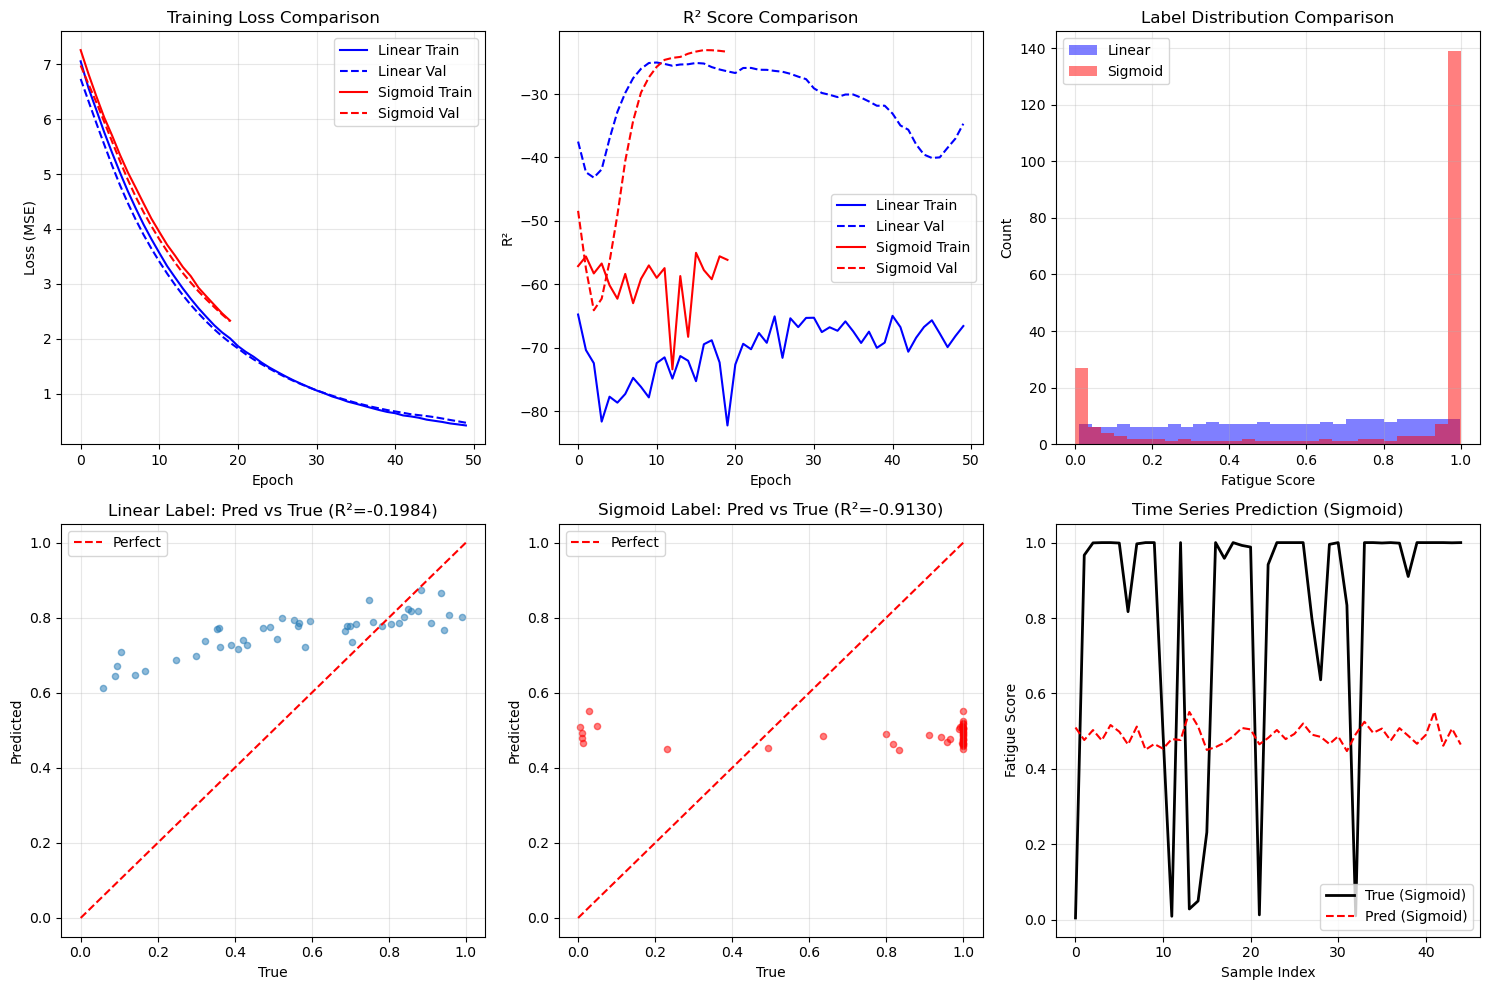


结果已保存: HFENN_Sigmoid_Single_Test_Results.png


In [11]:
# === Cell 11: 可视化对比 ===
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 训练Loss对比
axes[0, 0].plot(history_linear.history['loss'], label='Linear Train', color='blue', linestyle='-')
axes[0, 0].plot(history_linear.history['val_loss'], label='Linear Val', color='blue', linestyle='--')
axes[0, 0].plot(history_sigmoid.history['loss'], label='Sigmoid Train', color='red', linestyle='-')
axes[0, 0].plot(history_sigmoid.history['val_loss'], label='Sigmoid Val', color='red', linestyle='--')
axes[0, 0].set_title('Training Loss Comparison')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (MSE)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# R2对比
axes[0, 1].plot(history_linear.history['r2_metric'], label='Linear Train', color='blue', linestyle='-')
axes[0, 1].plot(history_linear.history['val_r2_metric'], label='Linear Val', color='blue', linestyle='--')
axes[0, 1].plot(history_sigmoid.history['r2_metric'], label='Sigmoid Train', color='red', linestyle='-')
axes[0, 1].plot(history_sigmoid.history['val_r2_metric'], label='Sigmoid Val', color='red', linestyle='--')
axes[0, 1].set_title('R² Score Comparison')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('R²')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 标签分布对比
axes[0, 2].hist(targets_linear, bins=30, alpha=0.5, label='Linear', color='blue')
axes[0, 2].hist(targets_sigmoid, bins=30, alpha=0.5, label='Sigmoid', color='red')
axes[0, 2].set_title('Label Distribution Comparison')
axes[0, 2].set_xlabel('Fatigue Score')
axes[0, 2].set_ylabel('Count')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 线性标签预测散点图
axes[1, 0].scatter(data_linear['y_test'], y_pred_linear, alpha=0.5, s=20)
axes[1, 0].plot([0, 1], [0, 1], 'r--', label='Perfect')
axes[1, 0].set_title(f'Linear Label: Pred vs True (R²={metrics_linear["R2"]:.4f})')
axes[1, 0].set_xlabel('True')
axes[1, 0].set_ylabel('Predicted')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Sigmoid标签预测散点图
axes[1, 1].scatter(data_sigmoid['y_test'], y_pred_sigmoid, alpha=0.5, s=20, color='red')
axes[1, 1].plot([0, 1], [0, 1], 'r--', label='Perfect')
axes[1, 1].set_title(f'Sigmoid Label: Pred vs True (R²={metrics_sigmoid["R2"]:.4f})')
axes[1, 1].set_xlabel('True')
axes[1, 1].set_ylabel('Predicted')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 时序预测对比
test_indices = np.arange(len(data_sigmoid['y_test']))
sorted_idx = np.argsort(test_indices)
axes[1, 2].plot(test_indices[sorted_idx], data_sigmoid['y_test'][sorted_idx], 'k-', label='True (Sigmoid)', linewidth=2)
axes[1, 2].plot(test_indices[sorted_idx], y_pred_sigmoid[sorted_idx], 'r--', label='Pred (Sigmoid)', linewidth=1.5)
axes[1, 2].set_title('Time Series Prediction (Sigmoid)')
axes[1, 2].set_xlabel('Sample Index')
axes[1, 2].set_ylabel('Fatigue Score')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('HFENN_Sigmoid_Single_Test_Results.png', dpi=150)
plt.show()

print(f"\n结果已保存: HFENN_Sigmoid_Single_Test_Results.png")

In [12]:
# === Cell 12: 总结 ===
print("="*60)
print(f"单受试者测试总结 ({TEST_PARTICIPANT})")
print("="*60)
print(f"\n线性标签模型:")
print(f"  最终训练Loss: {history_linear.history['loss'][-1]:.6f}")
print(f"  最终验证Loss: {history_linear.history['val_loss'][-1]:.6f}")
print(f"  测试R²: {metrics_linear['R2']:.4f}")

print(f"\nSigmoid标签模型:")
print(f"  最终训练Loss: {history_sigmoid.history['loss'][-1]:.6f}")
print(f"  最终验证Loss: {history_sigmoid.history['val_loss'][-1]:.6f}")
print(f"  测试R²: {metrics_sigmoid['R2']:.4f}")

print(f"\n对比结论:")
if metrics_sigmoid['R2'] > metrics_linear['R2']:
    print(f"  ✅ Sigmoid标签效果更好，建议全面应用")
elif metrics_sigmoid['R2'] == metrics_linear['R2']:
    print(f"  ⚠️ 两种标签效果相当")
else:
    print(f"  ❌ 线性标签效果更好，不建议更换")

单受试者测试总结 (gs1)

线性标签模型:
  最终训练Loss: 0.422264
  最终验证Loss: 0.471568
  测试R²: -0.1984

Sigmoid标签模型:
  最终训练Loss: 2.331484
  最终验证Loss: 2.319210
  测试R²: -0.9130

对比结论:
  ❌ 线性标签效果更好，不建议更换
